# TS1: Síntesis y operaciones de señales
### Gonzalo Constenla

El objetivo es analizar distintas las distintas señales propuestas; señales sinusoidales variando su amplitud (de distinta potencia), luego señales estocásticas; ruido de distribucion normal y de distribucion uniforme y luego una señal de pulso cuadrado. Luego observar y estudiar los cambios en la transformada de Fourier de estas señales.

### Marco Teórico
#### La transformada de Fourier
La transformada discreta de Fourier permite representar una señal discreta $ x[n] $ De N muestras en el dominio de la frecuencia, descomponiendola en las N frecuencias $ k $ presentes en la señal según la fórmula:

$$
X[k] = \sum_{n=0}^{N-1} x[n]e^{-j\frac{2\pi}{N}kn},
\qquad k=0,1,\ldots,N-1
$$


En la cual, $X[k]$ es un numero complejo con magnitud y fase que representa la contribucion de la frecuencia $k$. Se puede interpretar como un vector: $X[k] = Re{X[k]} + j·Im{X[k]}$, donde $Re{X[k]}$ es parte real e $ Im{X[k]}$ la parte imaginaria. Por lo cual tomamos el módulo:
$$
|X[k]| = \sqrt{\operatorname{Re}\{X[k]\}^2 + \operatorname{Im}\{X[k]\}^2}
$$
el cual que nos permite analizar la amplitud de cada frecuencia.
En este trabajo se utiliza la transformada rapida de Fourier  (FFT), un algoritmo eficiente para calcular la DFT.


### DESARROLLO

Importo librerias a utilizar y defino algunos parametros:

In [6]:

import numpy as np
import matplotlib.pyplot as plt
import scipy

N = 1000
f0 = 2000
fs = 20000
n = np.arange(N)
t = n / fs

delta_f = fs / N  # resolución espectral en hz = 20




#### SEÑAL 1
Para la señal 1 se pide: Señal sinusoidal de 2 KHz que tenga al menos 10 puntos por período.
La expresion matematica a utilizar para generar la señal sinusoidal es: $$
x[n] = A\sin(\omega_0 n + \phi)
$$


Por lo tanto defino: fs,  frecuencia de muestreo = 20000, tal que haya al menos 10 muestras por periodo según la siguiente inecuacion: $f_s \geq 10 \cdot f_0$

Para esta señal se utilizaron N = 1000 muestras. 

Genero la SEÑAL 1: Señal sinusoidal de 1 Watt. La grafico en t, tiempo total de muestreo y en T, un ciclo de señal.

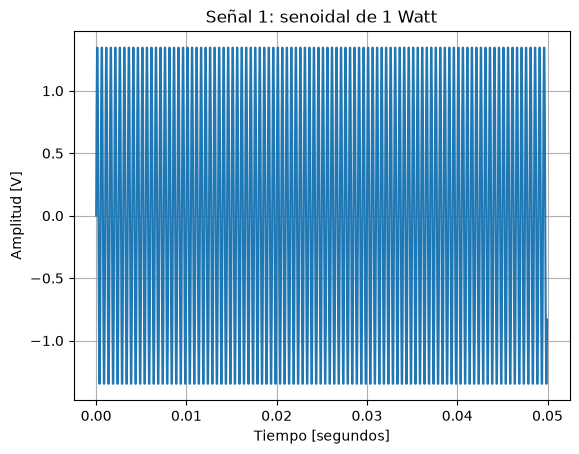

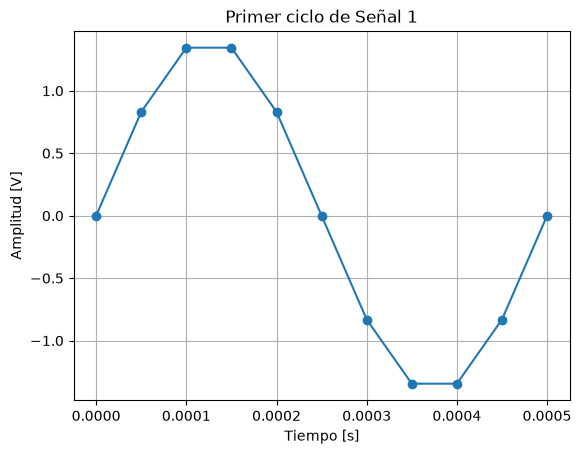

In [7]:
def mi_funcion_sen(vmax=1, dc=0, ff=1, ph=0, nn=N, fs=fs):

    tt = np.arange(nn) / fs

    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)

    return tt, xx


def graficar_primer_ciclo(t, x, f, titulo):
    muestras_por_ciclo = int(fs / f)

    plt.figure()
    plt.plot(t[:muestras_por_ciclo + 1], x[:muestras_por_ciclo + 1],'o-')
    plt.title(titulo)
    plt.xlabel('Tiempo [s]')
    plt.ylabel('Amplitud [V]')
    plt.grid()
    plt.show()

A1 = np.sqrt(2)

tt, xx = mi_funcion_sen(vmax=A1, dc=0, ff=f0, ph=0, nn=N, fs=fs)

plt.figure(1)
plt.plot(tt, xx)
plt.title('Señal 1: senoidal de 1 Watt')
plt.xlabel('Tiempo [segundos]')
plt.ylabel('Amplitud [V]')
plt.grid()
plt.show()

graficar_primer_ciclo(tt, xx, f0, 'Primer ciclo de Señal 1')

Y su transformada:

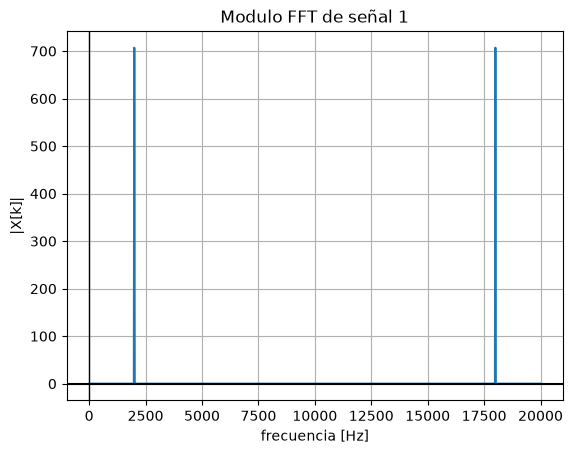

In [8]:
fft_1= scipy.fft.fft(xx)

modulo_1 = np.abs(fft_1)

frecuencias = np.arange(N) * delta_f

#

plt.figure(2)
plt.plot(frecuencias,modulo_1)
plt.title("Modulo FFT de señal 1")
plt.ylabel("|X[k]|")
plt.xlabel("frecuencia [Hz]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)

El espectro presenta 2 picos, el primero en 2000hz que coincide con el valor esperado ya que la señal fue generada con una frecuencia de 2000hz, por lo que la energía se concentra en esa frecuencia.

Luego aparece otro pico en 18000hz, que representa la componente de frecuencia negativa −2000 Hz.
Este pico aparece porque los senos pueden expresarse de forma exponencial segun la expresión
$$
\sin(\omega_0 n) = \frac{e^{j\omega_0 n} - e^{-j\omega_0 n}}{2j}
$$
De esta expresion se observa que una sinusoidal tiene componentes en las frecuencias f0 y -f0, de acá: la frecuencia de -2000hz.

Luego, la DFT es periodica con periódo fs, por lo que X(f) = X(f + fs). Y en concreto: X(f0=2000hz) = X(2000hz+20000hz). Y para la componente negativa tambien: X(-2000hz) = X(-2000hz + 20000hz)



### SEÑAL 2:
Aca utlizo la misma funcion para generar la funcion, cambiando el parametro de la amplitud, tal que la potencia sea de 2 Watts. Y la fase: φ = π/2

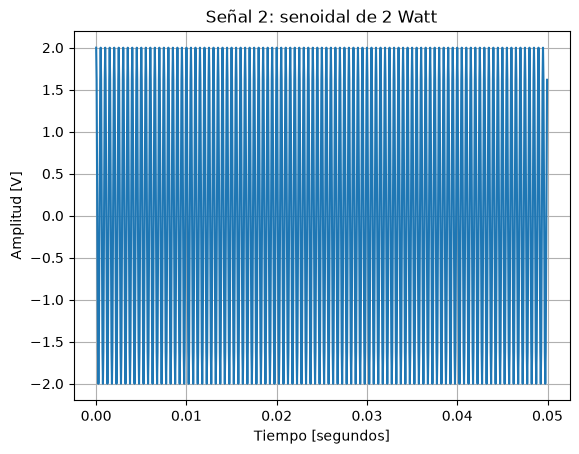

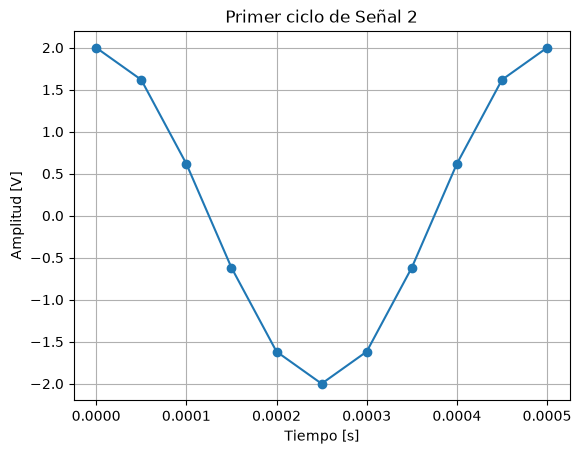

In [9]:
A2 = np.sqrt(2*2)

tt2, xx2 = mi_funcion_sen(vmax=A2, dc=0, ff=f0,ph=np.pi/2, nn=N, fs=fs)

plt.figure(3)
plt.plot(tt2, xx2)
plt.title('Señal 2: senoidal de 2 Watt')
plt.xlabel('Tiempo [segundos]')
plt.ylabel('Amplitud [V]')
plt.grid()
plt.show()

graficar_primer_ciclo(tt2, xx2, f0, 'Primer ciclo de Señal 2')

Ademas del cambio evidente en la fase se observa el cambio generado en la amplitud. Y como la potencia media de una sinusoidal es proporcional al cuadrado de su amplitud segun la expresión:
$$
P = \frac{A^2}{2}
$$
Aumentar la amplitud, aumenta la potencia.



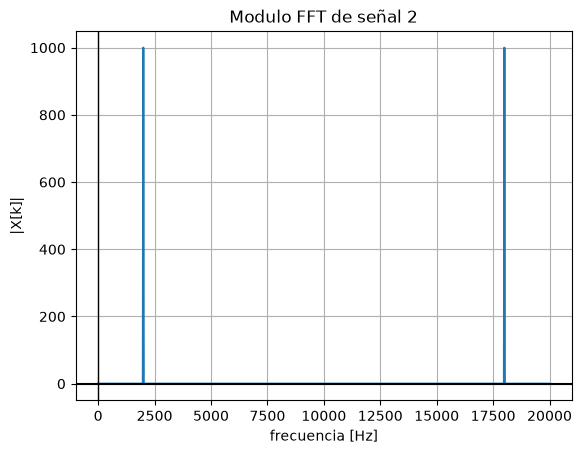

In [10]:
fft_2= scipy.fft.fft(xx2)

modulo_2 = np.abs(fft_2)

frecuencias2 = np.arange(N) * delta_f


plt.figure(4)
plt.plot(frecuencias2,modulo_2)
plt.title("Modulo FFT de señal 2")
plt.ylabel("|X[k]|")
plt.xlabel("frecuencia [Hz]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)

Aca se puede ver que el cambio de la potencia no tuvo influencia en la frecuencia donde figuran los picos, pero según lo esperado si se ve un cambio en la magnitud y los picos de la FFT aumentan.
Como la frecuencia no cambió, el espectro tiene picos exactamente en los mismos lugares: 2000hz y 18000hz.
Tambien vemos que el desfase no tiene influencia sobre los picos.

Por otro lado, si graficamos la FFT de la fase de la señal 1 y señal 2 se puede ver el desfase 

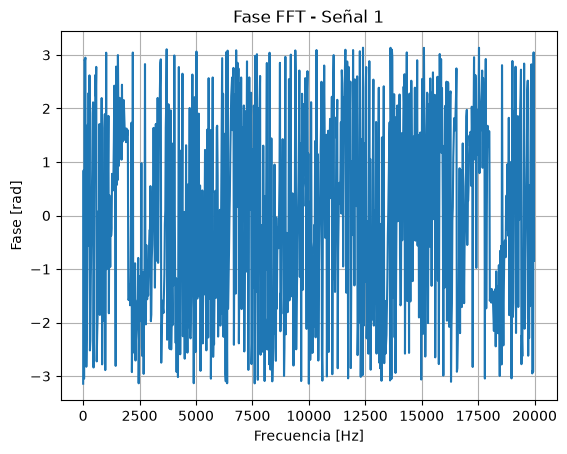

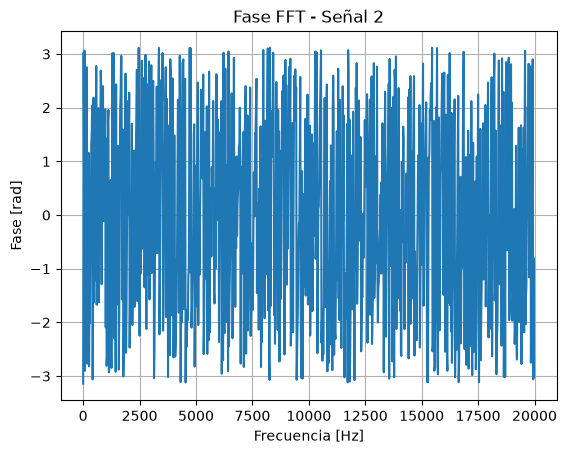

In [11]:
#%% diferencia de fase entre señal 1 y 2


fase_1 = np.angle(fft_1)
fase_2 = np.angle(fft_2)

plt.figure()
plt.plot(frecuencias, fase_1)
plt.title("Fase FFT - Señal 1")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Fase [rad]")
plt.grid()
plt.show()

plt.figure()
plt.plot(frecuencias, fase_2)
plt.title("Fase FFT - Señal 2")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Fase [rad]")
plt.grid()
plt.show()

### SEÑAL 3: Ruido normal
Genero la Señal de ruido de distribucion normal con valor medio = 0V y varianza = 0.1 W.

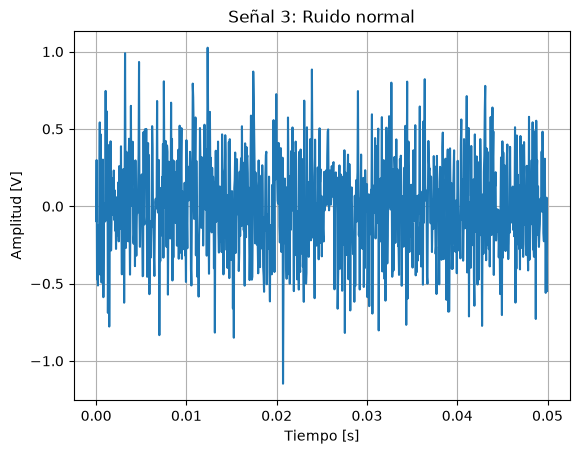

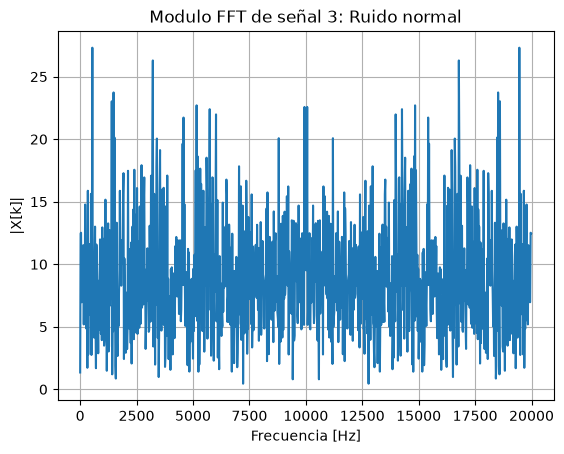

In [18]:
def gen_noise_normal(media=0, varianza=0.1, nn=N):

    desv_est = np.sqrt(varianza)

    ruido_normal = np.random.normal(media, desv_est, nn)

    return ruido_normal

ruido_normal = gen_noise_normal()

plt.figure(5)
plt.plot(t, ruido_normal)
plt.title("Señal 3: Ruido normal")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid()
plt.show()

fft_ruido_normal = scipy.fft.fft(ruido_normal)

modulo_ruido_normal = np.abs(fft_ruido_normal)

plt.figure(6)
plt.plot(frecuencias, modulo_ruido_normal)
plt.title("Modulo FFT de señal 3: Ruido normal")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("|X[k]|")
plt.grid()
plt.show()


A diferencia de las señales anteriores, el Ruido no posee una unica frecuencia definida, las frecuencias presentes en la señal se distribuyen a lo largo del espectro en distintas magnitudes(amplitud/modulo). Tambien se puede observar la simetria conjugada a aprtir de fs/2 = 10000, valor en frecuencia donde se encuentra el eje de simetría del espectro.

### SEÑAL 4: Ruido uniforme
Genero la Señal de ruido de distribucion uniforme con valor medio = 0V y varianza = 0.1 W.

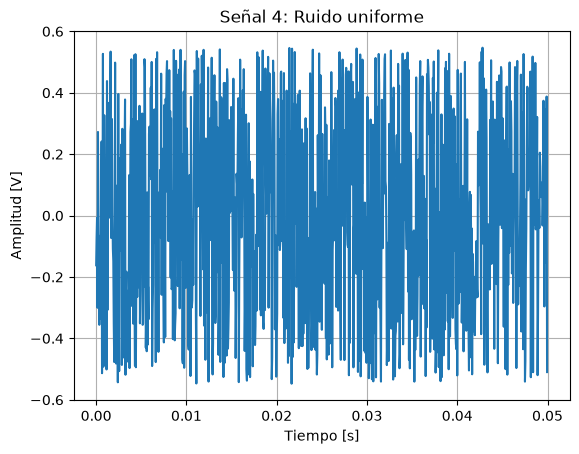

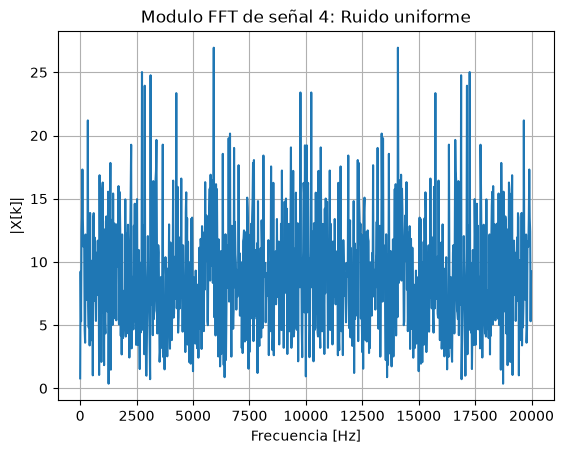

In [19]:

def gen_noise_uniforme(varianza=0.1, nn=N):

    a = np.sqrt(3 * varianza)

    ruido_uniforme = np.random.uniform(-a, a, nn)

    return ruido_uniforme
ruido_uniforme = gen_noise_uniforme(varianza=0.1)

plt.figure(7)
plt.plot(t, ruido_uniforme)
plt.title("Señal 4: Ruido uniforme")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid()
plt.show()


fft_ruido_uniforme = scipy.fft.fft(ruido_uniforme)

modulo_ruido_uniforme = np.abs(fft_ruido_uniforme)

plt.figure(8)
plt.plot(frecuencias, modulo_ruido_uniforme)
plt.title("Modulo FFT de señal 4: Ruido uniforme")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("|X[k]|")
plt.grid()
plt.show()


### SEÑAL 5: Pulso Rectangular
Genero una señal de Pulso Rectangular con misma frecuencia, de potencia = 1 Watt y Ciclo de Actividad = 0.5


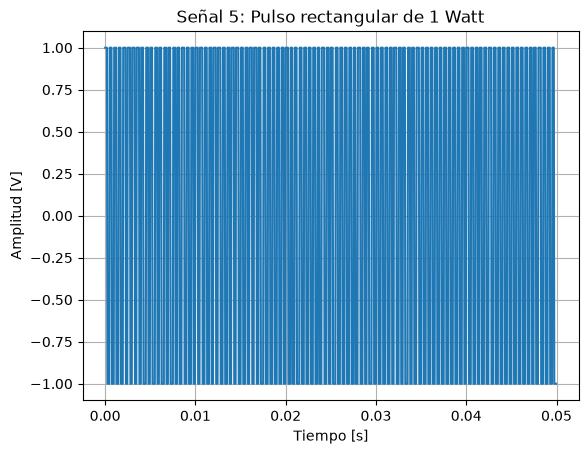

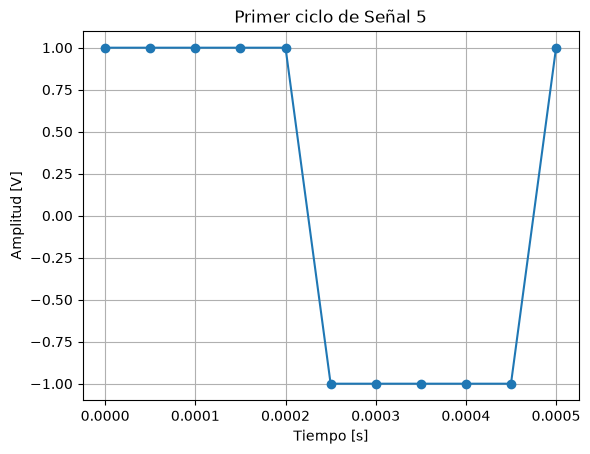

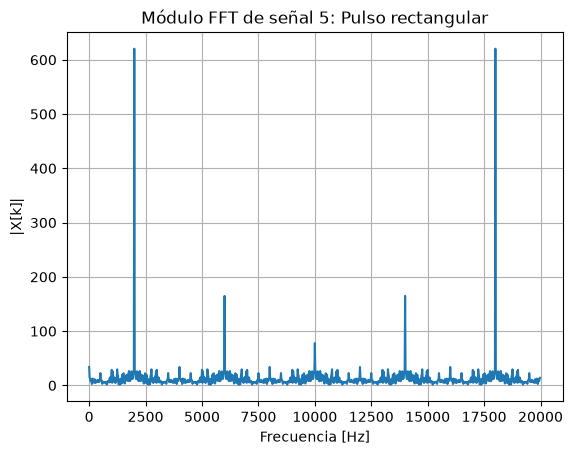

In [21]:
def mi_funcion_pulso_rectangular(vmax=1, ff=1, duty=0.5, nn=N, fs=fs):

    tt = np.arange(nn) / fs

    xx = vmax * scipy.signal.square(2 * np.pi * ff * tt, duty=duty)

    return tt, xx

    
A5 = 1
duty5 = 0.5


tt5, xx5 = mi_funcion_pulso_rectangular(vmax=A5, ff=f0, duty=duty5, nn=N, fs=fs)

plt.figure(9)
plt.plot(tt5, xx5)
plt.title("Señal 5: Pulso rectangular de 1 Watt")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid()
plt.show()

graficar_primer_ciclo(tt5, xx5, f0, 'Primer ciclo de Señal 5')

# Transformada de señal 5
fft_5 = scipy.fft.fft(xx5)

modulo_5 = np.abs(fft_5)

plt.figure(10)
plt.plot(frecuencias, modulo_5)
plt.title("Módulo FFT de señal 5: Pulso rectangular")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("|X[k]|")
plt.grid()
plt.show()